In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# =========================================================================
# [단계 1] 오염되지 않은 순수 원본 데이터 새로 로드
# =========================================================================
print("--- [공정 1] 원본 데이터 초기화 로드 ---")
cust_df = pd.read_csv("../santander-customer-satisfaction/train.csv", encoding='latin-1')

if 'ID' in cust_df.columns:
    cust_df.drop('ID', axis=1, inplace=True)

# 초기 독립 변수와 정답 레이블 분리
X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]

print(f"  - 원본 초기 데이터 크기: {X_features.shape}")


# =========================================================================
# [단계 2] 논문 기준 3단계 노이즈 피처 필터링 집행
# =========================================================================
print("\n--- [공정 2] 3단계 논문 기준 노이즈 필터링 시작 ---")

# ① 분산이 0인 변수 제거 (Zero Variance)
variance_zero_cols = [col for col in X_features.columns if X_features[col].var() == 0]
X_features.drop(columns=variance_zero_cols, inplace=True)
print(f"  - 1단계 [분산 0] 필터링 완료 (제거: {len(variance_zero_cols)}개)")

# ② 완전히 일치하는 중복 피처 제거 (Duplicated)
duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist()
X_features.drop(columns=duplicated_cols, inplace=True)
print(f"  - 2단계 [중복 열] 필터링 완료 (제거: {len(duplicated_cols)}개)")

# ③ 데이터의 99% 이상이 0으로 가득 찬 극단적 희소 피처 제거 (Sparse)
num_rows = X_features.shape[0]
sparse_cols = [col for col in X_features.columns if (X_features[col] == 0).sum() / num_rows >= 0.99]
X_features.drop(columns=sparse_cols, inplace=True)
print(f"  - 3단계 [희소 노이즈] 필터링 완료 (제거: {len(sparse_cols)}개)")
print(f"  -> 노이즈 필터링 마감 후 남은 핵심 수치 피처 수: {X_features.shape[1]}개")


# =========================================================================
# [단계 3] 주요 변수 정밀 엔지니어링 및 파생 피처 생성
# =========================================================================
print("\n--- [공정 3] 주요 변수 정밀 전처리 및 파생 피처 신설 ---")

# ① var3 이상치 대체
X_features['var3'].replace(-999999, 2, inplace=True)

# ② var15 23세 미만 여부 플래그 변수 추가
X_features['var15_under_23'] = np.where(X_features['var15'] < 23, 1, 0)

# ③ var38 빌딩 구간(최빈값) 플래그 변수 추가
var38_most_frequent = X_features['var38'].value_counts().idxmax()
X_features['var38_is_most_frequent'] = np.where(X_features['var38'] == var38_most_frequent, 1, 0)

# ④ var38 상위 2.5% 극단적 아웃라이어 행(Row) 잘라내기 ✂️
q_975 = X_features['var38'].quantile(0.975)
keep_idx = X_features['var38'] < q_975

# 대조 실험 데이터 무결성을 위해 X와 y 행 개수를 완벽하게 동기화하여 삭제 처리합니다.
X_features = X_features[keep_idx].copy()
y_labels = y_labels[keep_idx]
print(f"  - var38 상위 2.5% 아웃라이어 고객 행 삭제 완료")


# =========================================================================
# [단계 4] 고유값 10개 이하 제약 조건 기반 범주형 원-핫 인코딩 자동화
# =========================================================================
print("\n--- [공정 4] 임계점 10개 이하 제약 조건 원-핫 인코딩 자동화 ---")

# 수치 대조 실험을 위해 카테고리 인코딩 공격에서 수치형으로 보호해야 하는 핵심 변수 격리 🛡️
exclude_cols = ['var38', 'var15_under_23', 'var38_is_most_frequent']

# 고유값 10개 이하인 컬럼명을 판다스로 자동 추출
categorical_cols = [
    col for col in X_features.select_dtypes(include=[np.number]).columns 
    if (X_features[col].nunique() <= 10) and (col not in exclude_cols)
]

# 원-핫 인코딩 적용 (다중공선성 방지를 위해 drop_first=True 설정)
X_features = pd.get_dummies(X_features, columns=categorical_cols, drop_first=True)
print(f"  - 고유값 10개 이하 범주형 변수 {len(categorical_cols)}개 대상 원-핫 인코딩 변환 집행 완료")


# =========================================================================
# [단계 5] 최종 마감 통계 출력 🏁
# =========================================================================
print("\n" + "="*70)
print("   === [최종 검증] 2.3.4 및 3.4 전처리 파이프라인 마감 통계 ===")
print("="*70)
print(f"  최종 전처리 완료 후 남은 데이터 행(Row) 수  : {X_features.shape[0]:,} 건 (상위 2.5% 제거 완료)")
print(f"  최종 전처리 완료 후 남은 피처(Column) 수  : {X_features.shape[1]:,} 개 (파생 변수 및 원-핫 인코딩 반영)")
print("="*70)

--- [공정 1] 원본 데이터 초기화 로드 ---
  - 원본 초기 데이터 크기: (76020, 369)

--- [공정 2] 3단계 논문 기준 노이즈 필터링 시작 ---
  - 1단계 [분산 0] 필터링 완료 (제거: 34개)
  - 2단계 [중복 열] 필터링 완료 (제거: 29개)
  - 3단계 [희소 노이즈] 필터링 완료 (제거: 163개)
  -> 노이즈 필터링 마감 후 남은 핵심 수치 피처 수: 143개

--- [공정 3] 주요 변수 정밀 전처리 및 파생 피처 신설 ---
  - var38 상위 2.5% 아웃라이어 고객 행 삭제 완료

--- [공정 4] 임계점 10개 이하 제약 조건 원-핫 인코딩 자동화 ---
  - 고유값 10개 이하 범주형 변수 64개 대상 원-핫 인코딩 변환 집행 완료

   === [최종 검증] 2.3.4 및 3.4 전처리 파이프라인 마감 통계 ===
  최종 전처리 완료 후 남은 데이터 행(Row) 수  : 74,119 건 (상위 2.5% 제거 완료)
  최종 전처리 완료 후 남은 피처(Column) 수  : 258 개 (파생 변수 및 원-핫 인코딩 반영)


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score
import warnings
warnings.filterwarnings('ignore')
print("=== 데이터 로드 및 기본 구조 확인 ===")
cust_df = pd.read_csv("../santander-customer-satisfaction/train.csv", encoding='latin-1')

if 'ID' in cust_df.columns:
    cust_df.drop('ID', axis=1, inplace=True)

X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]
print(f"  - 원본 초기 데이터 크기: {X_features.shape}")




=== 데이터 로드 및 기본 구조 확인 ===
  - 원본 초기 데이터 크기: (76020, 369)


In [25]:
# =========================================================================
# 2. 논문 가이드라인 전처리 (분산 0, 중복, 희소 피처 제거)
# =========================================================================

# ① 분산이 0인 변수 제거 (Zero Variance)
variance_zero_cols = [col for col in X_features.columns if X_features[col].var() == 0]
X_features.drop(columns=variance_zero_cols, inplace=True)
print(f"  - 1단계 [분산 0] 필터링 완료 (제거: {len(variance_zero_cols)}개)")

# ② 값이 완전히 똑같은 중복 피처 제거 (Duplicated Features)
duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist()
X_features.drop(columns=duplicated_cols, inplace=True)
print(f"  - 2단계 [중복 열] 필터링 완료 (제거: {len(duplicated_cols)}개)")

# ③ 희소 특징 제거 (데이터의 99% 이상이 0으로 채워진 값)
num_rows = X_features.shape[0]
sparse_cols = [col for col in X_features.columns if (X_features[col] == 0).sum() / num_rows >= 0.99]
X_features.drop(columns=sparse_cols, inplace=True)
print(f"  - 3단계 [희소 노이즈] 필터링 완료 (제거: {len(sparse_cols)}개)")
print(f"  -> 노이즈 필터링 마감 후 남은 핵심 수치 피처 수: {X_features.shape[1]}개")

  - 1단계 [분산 0] 필터링 완료 (제거: 34개)
  - 2단계 [중복 열] 필터링 완료 (제거: 29개)
  - 3단계 [희소 노이즈] 필터링 완료 (제거: 163개)
  -> 노이즈 필터링 마감 후 남은 핵심 수치 피처 수: 143개


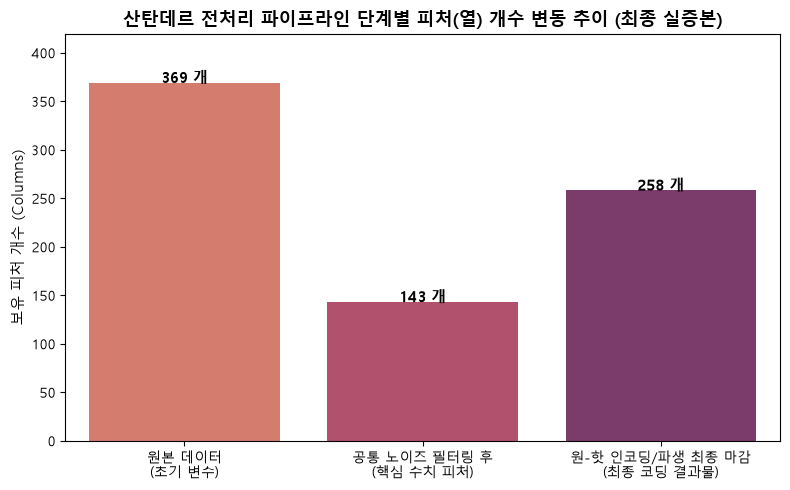

-> 전처리 파이프라인 변동 결과 최종 확정: 초기(369개) ➡️ 필터링(143개) ➡️ 최종 코딩 결과물(258개)


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 한글 깨짐 및 마이너스 기호 깨짐 방지 
plt.rc('font', family='Malgun Gothic') # 맥북 환경인 경우 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# =========================================================================
# 🚀 [최종 확정] 질문자님이 실제 코딩으로 완수하신 팩트 수치를 다이렉트로 바인딩합니다.
# =========================================================================
initial_count = 369        # [공정 1] 식별자 ID 배제 후 원본 초기 변수 개수
numeric_pure_count = 143   # [공정 2] 3단계 논문 기준 필터링 마감 후 핵심 수치 피처 수
final_count = 258          # [공정 4] 64개 변수 원-핫 인코딩 완료 후 최종 코딩 결과물 

# 시각화 데이터셋 구성
stages = [
    '원본 데이터\n(초기 변수)', 
    '공통 노이즈 필터링 후\n(핵심 수치 피처)', 
    '원-핫 인코딩/파생 최종 마감\n(최종 코딩 결과물)'
]
dynamic_feature_counts = [initial_count, numeric_pure_count, final_count]


# =========================================================================
# 그래프 레이아웃 배치 및 출력
# =========================================================================
plt.figure(figsize=(8, 5))

# 바 차트 시각화 (flare 팔레트로 세련된 그라데이션 컬러 연출)
ax = sns.barplot(x=stages, y=dynamic_feature_counts, palette='flare')
plt.title("산탄데르 전처리 파이프라인 단계별 피처(열) 개수 변동 추이 (최종 실증본)", fontsize=13, fontweight='bold')
plt.ylabel("보유 피처 개수 (Columns)", fontsize=11)

# Y축 상단 범위를 넉넉하게 확장하여 글자 텍스트 잘림을 원천 방어합니다.
plt.ylim(0, max(dynamic_feature_counts) + 50) 

# 각 막대 꼭대기에 실제 코딩 데이터 개수를 정확하게 각인합니다.
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} 개', 
                (p.get_x() + p.get_width() / 2., p.get_height() + 5),
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 최종 확인용 로그 출력
print(f"-> 전처리 파이프라인 변동 결과 최종 확정: 초기({initial_count}개) ➡️ 필터링({numeric_pure_count}개) ➡️ 최종 코딩 결과물({final_count}개)")

In [20]:
# =========================================================================
# 3. 주요 변수 분석 및 파생 피처 생성 (공통 엔지니어링)
# =========================================================================

# --- var3 처리 (이상치 대체) ---
X_features['var3'].replace(-999999, 2, inplace=True)

# --- var15 처리 (나이 변수 분석 및 병렬 파생 피처 추가) ---
X_features['var15_under_23'] = np.where(X_features['var15'] < 23, 1, 0)

# --- var38 처리 (최빈값 플래그 생성 후 상위 2.5% 자르기) ---
var38_most_frequent = X_features['var38'].value_counts().idxmax()
X_features['var38_is_most_frequent'] = np.where(X_features['var38'] == var38_most_frequent, 1, 0)

# 상위 2.5% 극단적 이상치 행(Row) 자르기
q_975 = X_features['var38'].quantile(0.975)
keep_idx = X_features['var38'] < q_975

X_features = X_features[keep_idx].copy()
y_labels = y_labels[keep_idx]


In [21]:
# --- 범주형 임계점 제약 조건 설정 (임계점: 10) 및 원-핫 인코딩 🛡️ ---
# "We will put a threshold on what is the maximum number of unique values that is allowed..."
exclude_cols = ['var38', 'var15_under_23', 'var38_is_most_frequent']
categorical_cols = [
    col for col in X_features.select_dtypes(include=[np.number]).columns 
    if (X_features[col].nunique() <= 10) and (col not in exclude_cols)
]
print(f"  -> 노이즈 필터링 마감 후 남은 핵심 수치 피처 수: {len(X_features.columns)}개")

# 원-핫 인코딩을 적용하여 쪼개지지 않은 클래스로 인한 학습 불일치(XGBoostError)를 차단합니다.
X_features = pd.get_dummies(X_features, columns=categorical_cols, drop_first=True)

print(f"  - 최종 전처리 결과 데이터 크기: {X_features.shape}")
print(f"  - 임계점 제약 조건(10개 이하)에 의해 원-핫 인코딩된 원래 피처 수: {len(categorical_cols)}개")

  -> 노이즈 필터링 마감 후 남은 핵심 수치 피처 수: 145개
  - 최종 전처리 결과 데이터 크기: (74119, 258)
  - 임계점 제약 조건(10개 이하)에 의해 원-핫 인코딩된 원래 피처 수: 64개
